# EWL Ablation Analysis
**FGVC-Aircraft** · LoRA ViT-Base

Compares EWL vs SFT baseline across:
- **Rank** ablation (r = 2, 4, 8, 16)
- **Temperature** ablation (τ = 1.0 – 3.0)
- **Alpha** ablation (α = 0.5 – 1.0)

All figures show **mean ± 1 std** across seeds {11, 22, 33}.

In [174]:
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

plt.rcParams.update({
    "figure.dpi": 130,
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "legend.framealpha": 0.9,
    "legend.fontsize": 9,
})

# NeurIPS-style palette: muted, print-safe, colourblind-friendly
C = {
    "ewl": "#2166AC",   # steel blue  — model of interest
    "sft": "#D6604D",   # muted red   — baseline
}
ALPHA_FILL = 0.15  # shading transparency

## 1. Load results

In [175]:
RESULTS_DIR = Path("../outputs/vision/aircraft_ablations")
SEEDS = [11, 22, 33]   # set to None to load all seeds

# ── directory name parsers ────────────────────────────────────────────────────
_EWL_RE  = re.compile(r"^r(\d+)_a([\d.]+)_t([\d.]+)_s(\d+)$")
_SFT_RE  = re.compile(r"^baseline_r(\d+)_s(\d+)$")

def _parse_dir(d: Path):
    """Return a metadata dict from a run directory name, or None if unrecognised."""
    name = d.name
    m = _EWL_RE.match(name)
    if m:
        return dict(condition="ewl",
                    rank=int(m[1]), alpha=float(m[2]),
                    temperature=float(m[3]), seed=int(m[4]))
    m = _SFT_RE.match(name)
    if m:
        return dict(condition="sft",
                    rank=int(m[1]), alpha=None,
                    temperature=None, seed=int(m[2]))
    return None

def load_runs(base: Path = RESULTS_DIR, seeds=SEEDS) -> pd.DataFrame:
    """
    Scan *base* for run directories, load the latest results_*.json in each,
    and return a tidy DataFrame with one row per run.

    seeds: list of ints to include, or None to load all seeds.

    Columns: condition, rank, alpha, temperature, seed,
             test_acc, test_f1, test_loss, history (list of dicts)
    """
    rows = []
    for d in sorted(base.iterdir()):
        if not d.is_dir():
            continue
        meta = _parse_dir(d)
        if meta is None:
            continue
        if seeds is not None and meta["seed"] not in seeds:
            continue
        jsons = sorted(d.glob("results_*.json"))
        if not jsons:
            continue
        with open(jsons[-1]) as f:   # latest by timestamp in filename
            payload = json.load(f)
        meta.update({
            "test_acc":  payload.get("test_acc"),
            "test_f1":   payload.get("test_f1"),
            "test_loss": payload.get("test_loss"),
            "history":   payload.get("history", []),
        })
        rows.append(meta)
    df = pd.DataFrame(rows)
    seed_str = str(seeds) if seeds else "all"
    print(f"Loaded {len(df)} runs  "
          f"({(df.condition=='ewl').sum()} EWL, {(df.condition=='sft').sum()} SFT)  "
          f"seeds={seed_str}")
    return df

df = load_runs()
df.drop(columns="history").sort_values(["condition","rank","alpha","temperature","seed"])

Loaded 51 runs  (39 EWL, 12 SFT)  seeds=[11, 22, 33]


,condition,rank,alpha,temperature,seed,test_acc,test_f1,test_loss
15,ewl,2,0.9,1.0,11,0.576658,0.575983,1.622721
16,ewl,2,0.9,1.0,22,0.572757,0.572452,1.631677
17,ewl,2,0.9,1.0,33,0.570357,0.571775,1.606360
18,ewl,4,0.5,1.0,11,0.574857,0.575274,1.581192
19,ewl,4,0.5,1.0,22,0.583258,0.585466,1.568151
20,ewl,4,0.5,1.0,33,0.580558,0.580254,1.547878
21,ewl,4,0.6,1.0,11,0.575458,0.575395,1.576506
22,ewl,4,0.6,1.0,22,0.586559,0.588132,1.561713
23,ewl,4,0.6,1.0,33,0.583858,0.584273,1.540213
24,ewl,4,0.7,1.0,11,0.574557,0.574855,1.566212


In [176]:
def get_curves(subset, metric="val_acc"):
    """Stack per-epoch metric from all runs. Returns (epochs, mean, std)."""
    series = []
    for _, row in subset.iterrows():
        vals = [ep[metric] for ep in row["history"] if ep.get(metric) is not None]
        series.append(vals)
    if not series:
        return [], [], []
    min_len = min(len(s) for s in series)
    arr = np.array([s[:min_len] for s in series])
    return np.arange(1, min_len + 1), arr.mean(0), arr.std(0)


def plot_curves(ax, subset_ewl, subset_sft, metric="val_acc",
                label_ewl="EWL", label_sft="SFT baseline"):
    """Plot mean ± std shaded curves for two subsets."""
    for subset, label, color in [
        (subset_ewl, label_ewl, C["ewl"]),
        (subset_sft, label_sft, C["sft"]),
    ]:
        ep, mu, sigma = get_curves(subset, metric)
        if len(ep) == 0:
            continue
        ax.plot(ep, mu, color=color, lw=2, label=label)
        ax.fill_between(ep, mu - sigma, mu + sigma, color=color, alpha=ALPHA_FILL)


def bar_with_err(ax, xs, ys_ewl, errs_ewl, ys_sft, errs_sft,
                 x_labels, xlabel, ylabel, title):
    """Grouped bar chart: EWL (left) vs SFT (right) per x-value."""
    xs_idx = np.arange(len(xs))
    w = 0.35
    bars_ewl = ax.bar(xs_idx - w/2, ys_ewl, w, yerr=errs_ewl,
                      color=C["ewl"], capsize=4, label="EWL", alpha=0.85)
    bars_sft = ax.bar(xs_idx + w/2, ys_sft, w, yerr=errs_sft,
                      color=C["sft"], capsize=4, label="SFT", alpha=0.85)
    ax.set_xticks(xs_idx)
    ax.set_xticklabels(x_labels)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    for bars, errs in [(bars_ewl, errs_ewl), (bars_sft, errs_sft)]:
        for bar, err in zip(bars, errs):
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + err + 0.002,
                    f"{h:.3f}", ha="center", va="bottom", fontsize=8)

print("Helpers defined.")

Helpers defined.


## Figure 1 — EWL vs SFT: Learning curves (best config)
Fixed config: rank=4, α=0.9, τ=2.0 · averaged over seeds {11, 22, 33}

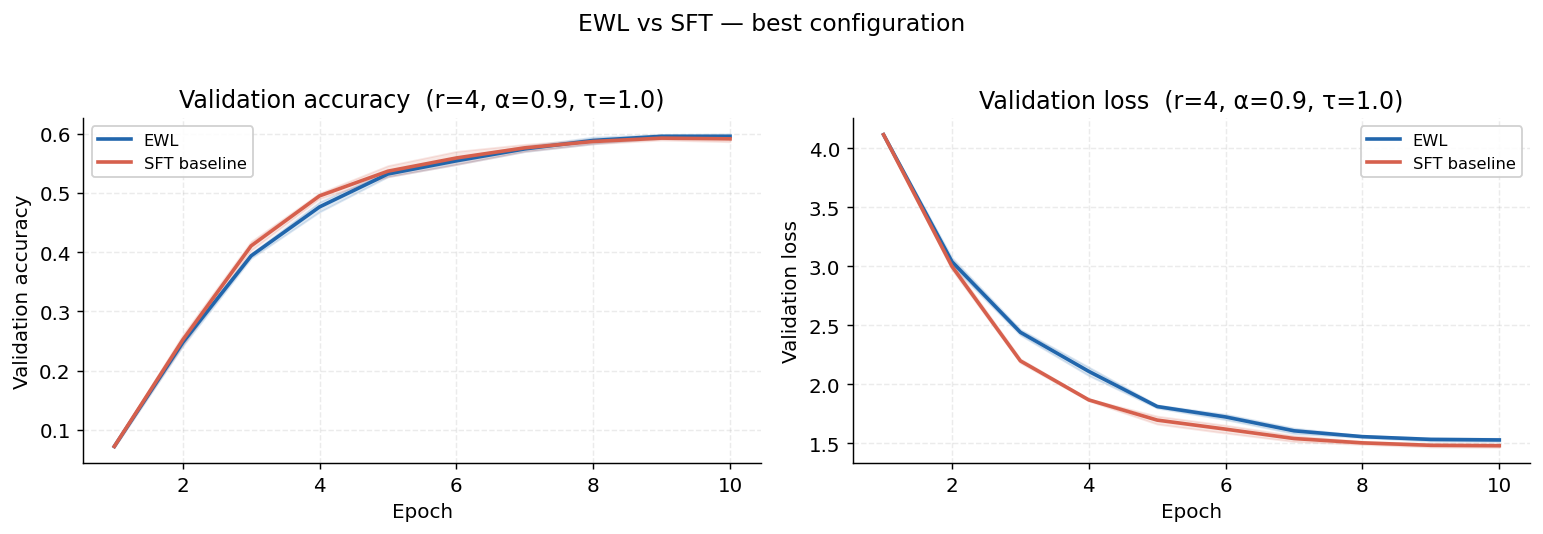

In [177]:
BEST_RANK, BEST_ALPHA, BEST_TEMP = 4, 0.9, 1.0

ewl_best = df[(df.condition == "ewl") &
              (df['rank'] == BEST_RANK) &
              (df.alpha == BEST_ALPHA) &
              (df.temperature == BEST_TEMP)]
sft_best = df[(df.condition == "sft") & (df['rank'] == BEST_RANK)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, ylabel in [
    (axes[0], "val_acc",  "Validation accuracy"),
    (axes[1], "val_loss", "Validation loss"),
]:
    plot_curves(ax, ewl_best, sft_best, metric=metric)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel}  (r={BEST_RANK}, α={BEST_ALPHA}, τ={BEST_TEMP})")
    ax.legend()

plt.suptitle("EWL vs SFT — best configuration", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Figure 2 — Rank ablation
Vary rank ∈ {2, 4, 8, 16} with fixed α=0.9, τ=2.0.
Left: final test accuracy · Right: learning curves per rank.

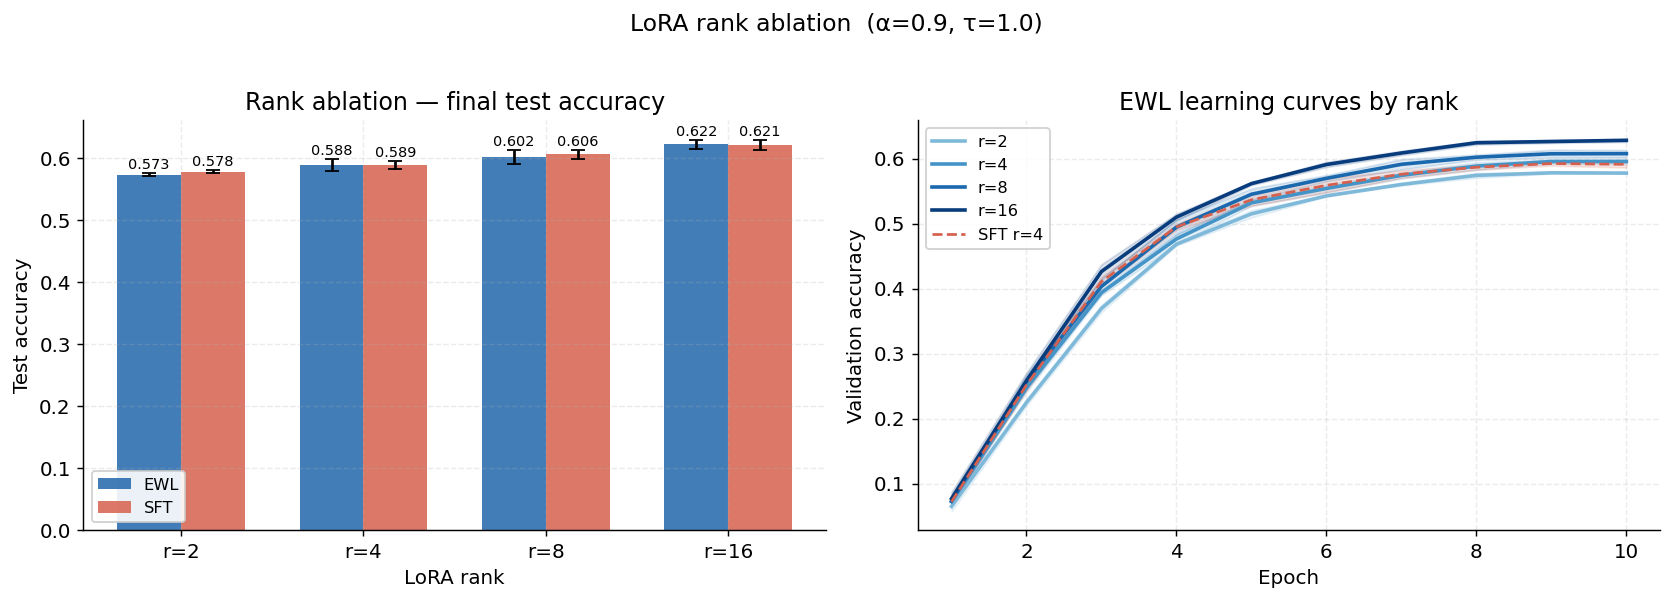

In [178]:
RANKS = [2, 4, 8, 16]

ys_ewl, errs_ewl = [], []
ys_sft, errs_sft = [], []

for r in RANKS:
    ewl_r = df[(df.condition == "ewl") & (df['rank'] == r) &
               (df.alpha == BEST_ALPHA) & (df.temperature == BEST_TEMP)]["test_acc"].dropna()
    sft_r = df[(df.condition == "sft") & (df['rank'] == r)]["test_acc"].dropna()
    ys_ewl.append(ewl_r.mean());  errs_ewl.append(ewl_r.std())
    ys_sft.append(sft_r.mean());  errs_sft.append(sft_r.std())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: grouped bar
bar_with_err(axes[0], RANKS, ys_ewl, errs_ewl, ys_sft, errs_sft,
             x_labels=[f"r={r}" for r in RANKS],
             xlabel="LoRA rank", ylabel="Test accuracy",
             title="Rank ablation — final test accuracy")

# Right: learning curves per rank (EWL only)
rank_colors = plt.cm.Blues(np.linspace(0.45, 0.95, len(RANKS)))
for r, col in zip(RANKS, rank_colors):
    sub = df[(df.condition == "ewl") & (df['rank'] == r) &
             (df.alpha == BEST_ALPHA) & (df.temperature == BEST_TEMP)]
    ep, mu, sigma = get_curves(sub, "val_acc")
    if len(ep) == 0:
        continue
    axes[1].plot(ep, mu, color=col, lw=2, label=f"r={r}")
    axes[1].fill_between(ep, mu - sigma, mu + sigma, color=col, alpha=ALPHA_FILL)

# Overlay SFT at best rank as reference
ep, mu, sigma = get_curves(sft_best, "val_acc")
if len(ep):
    axes[1].plot(ep, mu, color=C["sft"], lw=1.5, ls="--", label=f"SFT r={BEST_RANK}")
    axes[1].fill_between(ep, mu - sigma, mu + sigma, color=C["sft"], alpha=ALPHA_FILL)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation accuracy")
axes[1].set_title("EWL learning curves by rank")
axes[1].legend()

plt.suptitle("LoRA rank ablation  (α=0.9, τ=1.0)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Figure 3 — Temperature ablation
Vary τ ∈ {1.0, 1.5, 2.0, 2.5, 3.0} with fixed rank=4, α=0.9.

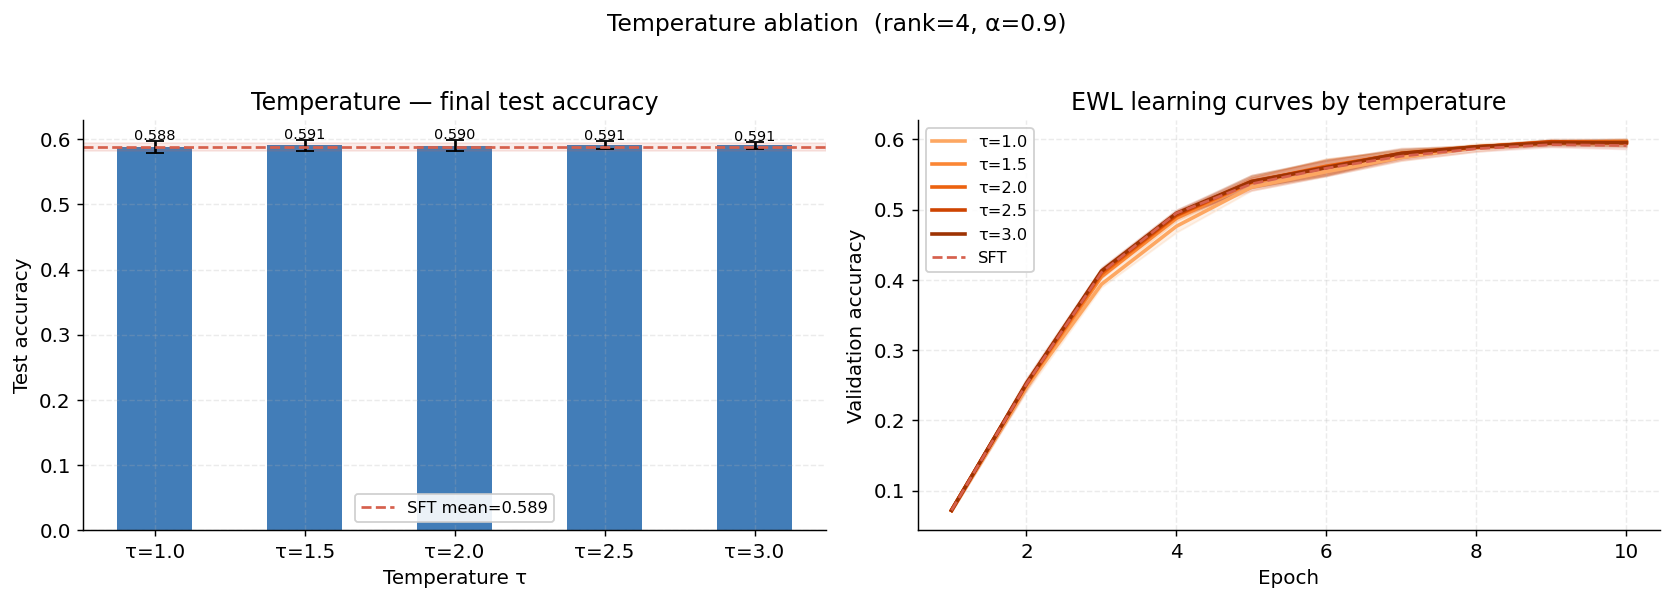

In [179]:
TEMPS = [1.0, 1.5, 2.0, 2.5, 3.0]

ys_t, errs_t = [], []
for t in TEMPS:
    sub = df[(df.condition == "ewl") & (df['rank'] == BEST_RANK) &
             (df.alpha == BEST_ALPHA) & (df.temperature == t)]["test_acc"].dropna()
    ys_t.append(sub.mean())
    errs_t.append(sub.std())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: bar chart
axes[0].bar(range(len(TEMPS)), ys_t, yerr=errs_t,
            color=C["ewl"], capsize=5, alpha=0.85, width=0.5)
# SFT reference line
sft_mu = df[(df.condition == "sft") & (df['rank'] == BEST_RANK)]["test_acc"].mean()
sft_std = df[(df.condition == "sft") & (df['rank'] == BEST_RANK)]["test_acc"].std()
axes[0].axhline(sft_mu, color=C["sft"], lw=1.5, ls="--", label=f"SFT mean={sft_mu:.3f}")
axes[0].axhspan(sft_mu - sft_std, sft_mu + sft_std, color=C["sft"], alpha=0.12)
for i, (y, e) in enumerate(zip(ys_t, errs_t)):
    axes[0].text(i, y + e + 0.002, f"{y:.3f}", ha="center", fontsize=8)
axes[0].set_xticks(range(len(TEMPS)))
axes[0].set_xticklabels([f"τ={t}" for t in TEMPS])
axes[0].set_xlabel("Temperature τ")
axes[0].set_ylabel("Test accuracy")
axes[0].set_title("Temperature — final test accuracy")
axes[0].legend()

# Right: learning curves per temperature
temp_colors = plt.cm.Oranges(np.linspace(0.4, 0.9, len(TEMPS)))
for t, col in zip(TEMPS, temp_colors):
    sub = df[(df.condition == "ewl") & (df['rank'] == BEST_RANK) &
             (df.alpha == BEST_ALPHA) & (df.temperature == t)]
    ep, mu, sigma = get_curves(sub, "val_acc")
    if len(ep) == 0:
        continue
    axes[1].plot(ep, mu, color=col, lw=2, label=f"τ={t}")
    axes[1].fill_between(ep, mu - sigma, mu + sigma, color=col, alpha=ALPHA_FILL)

ep, mu, sigma = get_curves(sft_best, "val_acc")
if len(ep):
    axes[1].plot(ep, mu, color=C["sft"], lw=1.5, ls="--", label="SFT")
    axes[1].fill_between(ep, mu - sigma, mu + sigma, color=C["sft"], alpha=ALPHA_FILL)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation accuracy")
axes[1].set_title("EWL learning curves by temperature")
axes[1].legend()

plt.suptitle("Temperature ablation  (rank=4, α=0.9)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Figure 4 — Alpha (EMA decay) ablation
Vary α ∈ {0.5, 0.6, 0.7, 0.8, 0.9, 1.0} with fixed rank=4, τ=2.0.

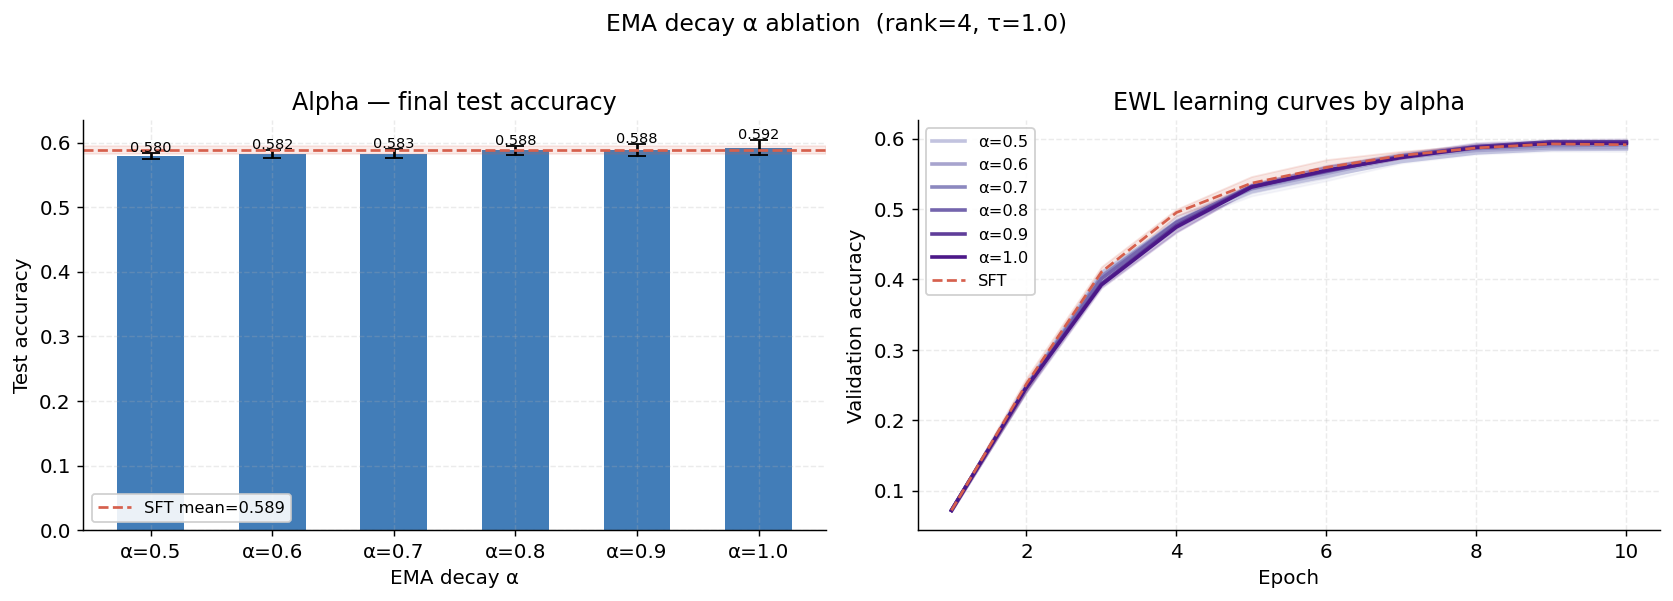

In [180]:
ALPHAS = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

ys_a, errs_a = [], []
for a in ALPHAS:
    sub = df[(df.condition == "ewl") & (df['rank'] == BEST_RANK) &
             (df.alpha == a) & (df.temperature == BEST_TEMP)]["test_acc"].dropna()
    ys_a.append(sub.mean())
    errs_a.append(sub.std())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: bar chart
axes[0].bar(range(len(ALPHAS)), ys_a, yerr=errs_a,
            color=C["ewl"], capsize=5, alpha=0.85, width=0.55)
axes[0].axhline(sft_mu, color=C["sft"], lw=1.5, ls="--", label=f"SFT mean={sft_mu:.3f}")
axes[0].axhspan(sft_mu - sft_std, sft_mu + sft_std, color=C["sft"], alpha=0.12)
for i, (y, e) in enumerate(zip(ys_a, errs_a)):
    axes[0].text(i, y + e + 0.002, f"{y:.3f}", ha="center", fontsize=8)
axes[0].set_xticks(range(len(ALPHAS)))
axes[0].set_xticklabels([f"α={a}" for a in ALPHAS])
axes[0].set_xlabel("EMA decay α")
axes[0].set_ylabel("Test accuracy")
axes[0].set_title("Alpha — final test accuracy")
axes[0].legend()

# Right: learning curves per alpha
alpha_colors = plt.cm.Purples(np.linspace(0.35, 0.92, len(ALPHAS)))
for a, col in zip(ALPHAS, alpha_colors):
    sub = df[(df.condition == "ewl") & (df['rank'] == BEST_RANK) &
             (df.alpha == a) & (df.temperature == BEST_TEMP)]
    ep, mu, sigma = get_curves(sub, "val_acc")
    if len(ep) == 0:
        continue
    axes[1].plot(ep, mu, color=col, lw=2, label=f"α={a}")
    axes[1].fill_between(ep, mu - sigma, mu + sigma, color=col, alpha=ALPHA_FILL)

ep, mu, sigma = get_curves(sft_best, "val_acc")
if len(ep):
    axes[1].plot(ep, mu, color=C["sft"], lw=1.5, ls="--", label="SFT")
    axes[1].fill_between(ep, mu - sigma, mu + sigma, color=C["sft"], alpha=ALPHA_FILL)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation accuracy")
axes[1].set_title("EWL learning curves by alpha")
axes[1].legend()

plt.suptitle("EMA decay α ablation  (rank=4, τ=1.0)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Figure 5 — Hyperparameter sensitivity summary
The sweep is a **cross**: alpha varies at fixed τ=2.0, temperature varies at fixed α=0.9.
Both are shown normalised to [0,1] so sensitivity magnitude is directly comparable.

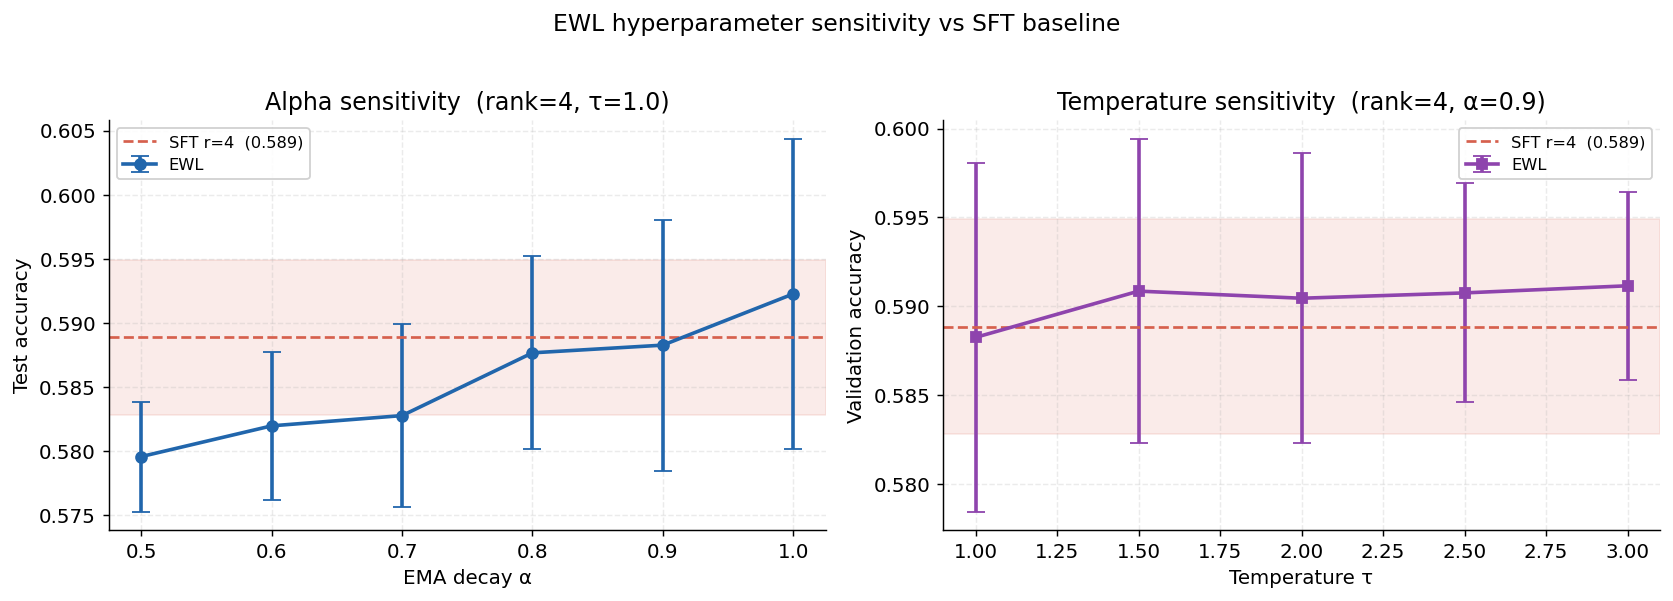

Alpha sensitivity (max−min): 0.0127
Temp  sensitivity (max−min): 0.0029
SFT baseline: 0.5889 ± 0.0060


In [181]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: alpha sensitivity at fixed τ=2.0
ys_a_arr = np.array(ys_a)
axes[0].errorbar(ALPHAS, ys_a_arr, yerr=errs_a,
                 fmt="o-", color=C["ewl"], lw=2, capsize=5, label="EWL")
axes[0].axhline(sft_mu, color=C["sft"], lw=1.5, ls="--",
                label=f"SFT r={BEST_RANK}  ({sft_mu:.3f})")
axes[0].axhspan(sft_mu - sft_std, sft_mu + sft_std, color=C["sft"], alpha=0.12)
axes[0].set_xlabel("EMA decay α")
axes[0].set_ylabel("Test accuracy")
axes[0].set_title(f"Alpha sensitivity  (rank={BEST_RANK}, τ={BEST_TEMP})")
axes[0].legend()

# Right: temperature sensitivity at fixed α=0.9
ys_t_arr = np.array(ys_t)
axes[1].errorbar(TEMPS, ys_t_arr, yerr=errs_t,
                 fmt="s-", color="#8E44AD", lw=2, capsize=5, label="EWL")
axes[1].axhline(sft_mu, color=C["sft"], lw=1.5, ls="--",
                label=f"SFT r={BEST_RANK}  ({sft_mu:.3f})")
axes[1].axhspan(sft_mu - sft_std, sft_mu + sft_std, color=C["sft"], alpha=0.12)
axes[1].set_xlabel("Temperature τ")
axes[1].set_ylabel("Validation accuracy")
axes[1].set_title(f"Temperature sensitivity  (rank={BEST_RANK}, α={BEST_ALPHA})")
axes[1].legend()

plt.suptitle("EWL hyperparameter sensitivity vs SFT baseline", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Alpha sensitivity (max−min): {np.nanmax(ys_a_arr) - np.nanmin(ys_a_arr):.4f}")
print(f"Temp  sensitivity (max−min): {np.nanmax(ys_t_arr) - np.nanmin(ys_t_arr):.4f}")
print(f"SFT baseline: {sft_mu:.4f} ± {sft_std:.4f}")

## Summary table
Best EWL configuration vs SFT baseline across all ranks.

In [182]:
rows = []
for r in RANKS:
    ewl_r = df[(df.condition == "ewl") & (df['rank'] == r) &
               (df.alpha == BEST_ALPHA) & (df.temperature == BEST_TEMP)]["test_acc"].dropna()
    sft_r = df[(df.condition == "sft") & (df['rank'] == r)]["test_acc"].dropna()
    if len(ewl_r) == 0 and len(sft_r) == 0:
        continue
    ewl_mu = ewl_r.mean() if len(ewl_r) else float("nan")
    ewl_sd = ewl_r.std()  if len(ewl_r) else float("nan")
    sft_mu_r = sft_r.mean() if len(sft_r) else float("nan")
    sft_sd_r = sft_r.std()  if len(sft_r) else float("nan")
    rows.append({
        "Rank": r,
        "EWL test acc": f"{ewl_mu:.4f} ± {ewl_sd:.4f}" if not np.isnan(ewl_mu) else "—",
        "SFT test acc": f"{sft_mu_r:.4f} ± {sft_sd_r:.4f}" if not np.isnan(sft_mu_r) else "—",
        "Δ (EWL−SFT)":  f"{ewl_mu - sft_mu_r:+.4f}" if not (np.isnan(ewl_mu) or np.isnan(sft_mu_r)) else "—",
        "EWL seeds": len(ewl_r),
        "SFT seeds": len(sft_r),
    })

summary = pd.DataFrame(rows).set_index("Rank")
print(f"Config: α={BEST_ALPHA}, τ={BEST_TEMP}\n")
summary

Config: α=0.9, τ=1.0



,EWL test acc,SFT test acc,Δ (EWL−SFT),EWL seeds,SFT seeds
Rank,,,,,
2,0.5733 ± 0.0032,0.5780 ± 0.0030,-0.0047,3,3
4,0.5883 ± 0.0098,0.5889 ± 0.0060,-0.0006,3,3
8,0.6017 ± 0.0110,0.6059 ± 0.0068,-0.0042,3,3
16,0.6219 ± 0.0067,0.6215 ± 0.0079,+0.0004,3,3


---
## Noise & Imbalance Ablations
Results from `sweep_noise_imbalance.py` — fixed rank=4, α=0.9, τ=2.0, seed=11.
Single seed so no std shading on bars; learning curves are single runs.

In [183]:
# ── Load noise & imbalance results ───────────────────────────────────────────
import re, json, numpy as np, pandas as pd
from pathlib import Path

NI_DIR  = Path("../outputs/vision/aircraft_noise_imbalance")
NI_SEED = 11   # set to None to load all seeds
# ── Fixed hyperparams: read from sweep script (not hardcoded) ───────────────
_sweep_src = (Path("../scripts/sweep_noise_imbalance.py")).read_text()
NI_RANK  = int(re.search(r'^RANK\s*=\s*(\d+)',       _sweep_src, re.M).group(1))
NI_ALPHA = float(re.search(r'^ALPHA\s*=\s*([\d.]+)',  _sweep_src, re.M).group(1))
NI_TEMP  = float(re.search(r'^TEMPERATURE\s*=\s*([\d.]+)', _sweep_src, re.M).group(1))
print(f"NI sweep fixed params: rank={NI_RANK}, alpha={NI_ALPHA}, temperature={NI_TEMP}")


_NOISE_EWL_RE = re.compile(r"^ewl_noise(\d+)pct_s(\d+)$")
_NOISE_SFT_RE = re.compile(r"^sft_noise(\d+)pct_s(\d+)$")
_IMB_EWL_RE   = re.compile(r"^ewl_imb(\d+)_s(\d+)$")
_IMB_SFT_RE   = re.compile(r"^sft_imb(\d+)_s(\d+)$")

def _parse_ni_dir(d):
    n = d.name
    for pattern, cond, sweep in [
        (_NOISE_EWL_RE, "ewl", "noise"),
        (_NOISE_SFT_RE, "sft", "noise"),
        (_IMB_EWL_RE,   "ewl", "imbalance"),
        (_IMB_SFT_RE,   "sft", "imbalance"),
    ]:
        m = pattern.match(n)
        if m:
            return dict(condition=cond, sweep=sweep,
                        value=int(m[1]), seed=int(m[2]))
    return None

def load_ni_runs(base=NI_DIR, seed=NI_SEED):
    """
    Load noise & imbalance runs.
    seed: single int to filter by, or None to load all seeds.
    Always picks the latest results_*.json in each directory.
    """
    rows = []
    for d in sorted(base.iterdir()):
        if not d.is_dir():
            continue
        meta = _parse_ni_dir(d)
        if meta is None:
            continue
        if seed is not None and meta["seed"] != seed:
            continue
        jsons = sorted(d.glob("results_*.json"))
        if not jsons:# or len(jsons) != 3:
            continue
        with open(jsons[-1]) as f:   # latest by timestamp in filename
            payload = json.load(f)
        meta.update({
            "test_acc":  payload.get("test_acc"),
            "test_f1":   payload.get("test_f1"),
            "test_loss": payload.get("test_loss"),
            "history":   payload.get("history", []),
        })
        rows.append(meta)
    df_ni = pd.DataFrame(rows)
    print(f"Loaded {len(df_ni)} NI runs  "
          f"({(df_ni.condition=='ewl').sum()} EWL, {(df_ni.condition=='sft').sum()} SFT)  "
          f"seed={seed}")
    return df_ni

df_ni = load_ni_runs()
df_ni.drop(columns="history").sort_values(["sweep","value","condition"])

NI sweep fixed params: rank=4, alpha=0.9, temperature=1.0
Loaded 20 NI runs  (10 EWL, 10 SFT)  seed=11


,condition,sweep,value,seed,test_acc,test_f1,test_loss
4,ewl,imbalance,5,11,0.234023,0.211353,3.779141
14,sft,imbalance,5,11,0.227423,0.205104,3.695604
1,ewl,imbalance,10,11,0.309331,0.302407,3.054213
11,sft,imbalance,10,11,0.298230,0.288849,2.984169
2,ewl,imbalance,20,11,0.396340,0.394582,2.435492
12,sft,imbalance,20,11,0.394239,0.391653,2.381169
3,ewl,imbalance,50,11,0.512751,0.513791,1.888157
13,sft,imbalance,50,11,0.514551,0.514091,1.829580
0,ewl,imbalance,100,11,0.579358,0.579119,1.561439
10,sft,imbalance,100,11,0.583858,0.583515,1.507722


## Figure 6 — Label noise ablation
Vary noise fraction ∈ {10%, 20%, 30%, 40%} · fixed rank=4, α=0.9, τ=2.0, seed=11.

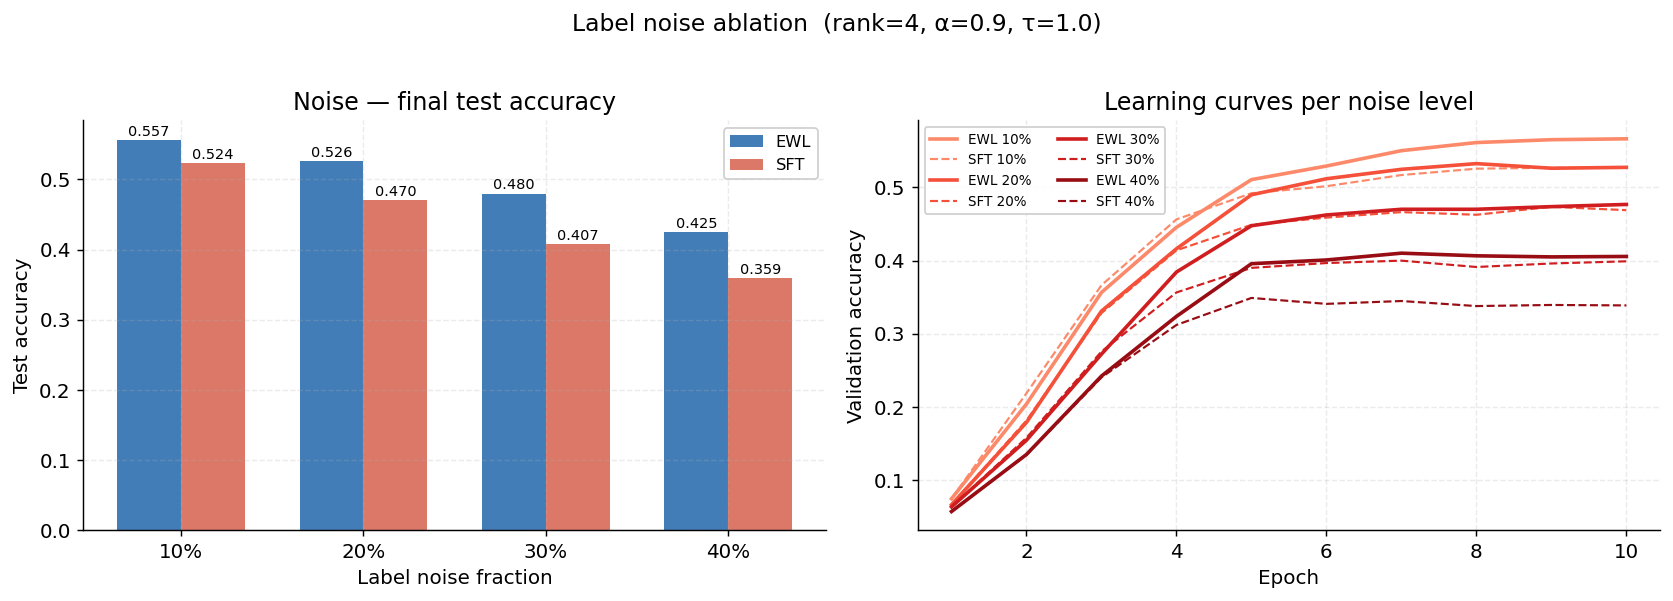

EWL test acc: ['0.5566', '0.5257', '0.4797', '0.4251']
SFT test acc: ['0.5236', '0.4701', '0.4074', '0.3594']
Δ (EWL−SFT): ['+0.0330', '+0.0555', '+0.0723', '+0.0657']


In [184]:
NOISE_LEVELS = [10, 20, 30, 40]   # percent

noise = df_ni[df_ni.sweep == 'noise'].copy()

acc_ewl_n = [noise[(noise.condition=='ewl') & (noise['value']==v)]['test_acc'].values for v in NOISE_LEVELS]
acc_sft_n = [noise[(noise.condition=='sft') & (noise['value']==v)]['test_acc'].values for v in NOISE_LEVELS]

y_ewl_n = [a[0] if len(a) else float('nan') for a in acc_ewl_n]
y_sft_n = [a[0] if len(a) else float('nan') for a in acc_sft_n]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: bar chart
xs = np.arange(len(NOISE_LEVELS))
w = 0.35
bars_e = axes[0].bar(xs - w/2, y_ewl_n, w, color=C['ewl'], alpha=0.85, label='EWL')
bars_s = axes[0].bar(xs + w/2, y_sft_n, w, color=C['sft'], alpha=0.85, label='SFT')
for bar, y in list(zip(bars_e, y_ewl_n)) + list(zip(bars_s, y_sft_n)):
    if not np.isnan(y):
        axes[0].text(bar.get_x() + bar.get_width()/2, y + 0.002,
                     f'{y:.3f}', ha='center', va='bottom', fontsize=8)
axes[0].set_xticks(xs)
axes[0].set_xticklabels([f'{v}%' for v in NOISE_LEVELS])
axes[0].set_xlabel('Label noise fraction')
axes[0].set_ylabel('Test accuracy')
axes[0].set_title('Noise — final test accuracy')
axes[0].legend()

# Right: learning curves (val_acc)
noise_colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(NOISE_LEVELS)))
for v, col in zip(NOISE_LEVELS, noise_colors):
    for cond, ls in [('ewl', '-'), ('sft', '--')]:
        sub = noise[(noise.condition==cond) & (noise['value']==v)]
        ep, mu, _ = get_curves(sub, 'val_acc')
        if len(ep) == 0: continue
        lbl = f'{cond.upper()} {v}%'
        axes[1].plot(ep, mu, color=col, lw=2 if cond=='ewl' else 1.2,
                     ls=ls, label=lbl)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation accuracy')
axes[1].set_title('Learning curves per noise level')
axes[1].legend(fontsize=7.5, ncol=2)

plt.suptitle(f'Label noise ablation  (rank={NI_RANK}, α={NI_ALPHA}, τ={NI_TEMP})', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('EWL test acc:', [f'{v:.4f}' for v in y_ewl_n])
print('SFT test acc:', [f'{v:.4f}' for v in y_sft_n])
print('Δ (EWL−SFT):', [f'{e-s:+.4f}' for e, s in zip(y_ewl_n, y_sft_n)])

## Figure 7 — Class imbalance ablation
Vary imbalance factor: code 50→ratio=0.5 (mild), 20→0.2, 10→0.1, 5→0.05 (severe).
Lower ratio = higher class imbalance factor (IF = 1/ratio).

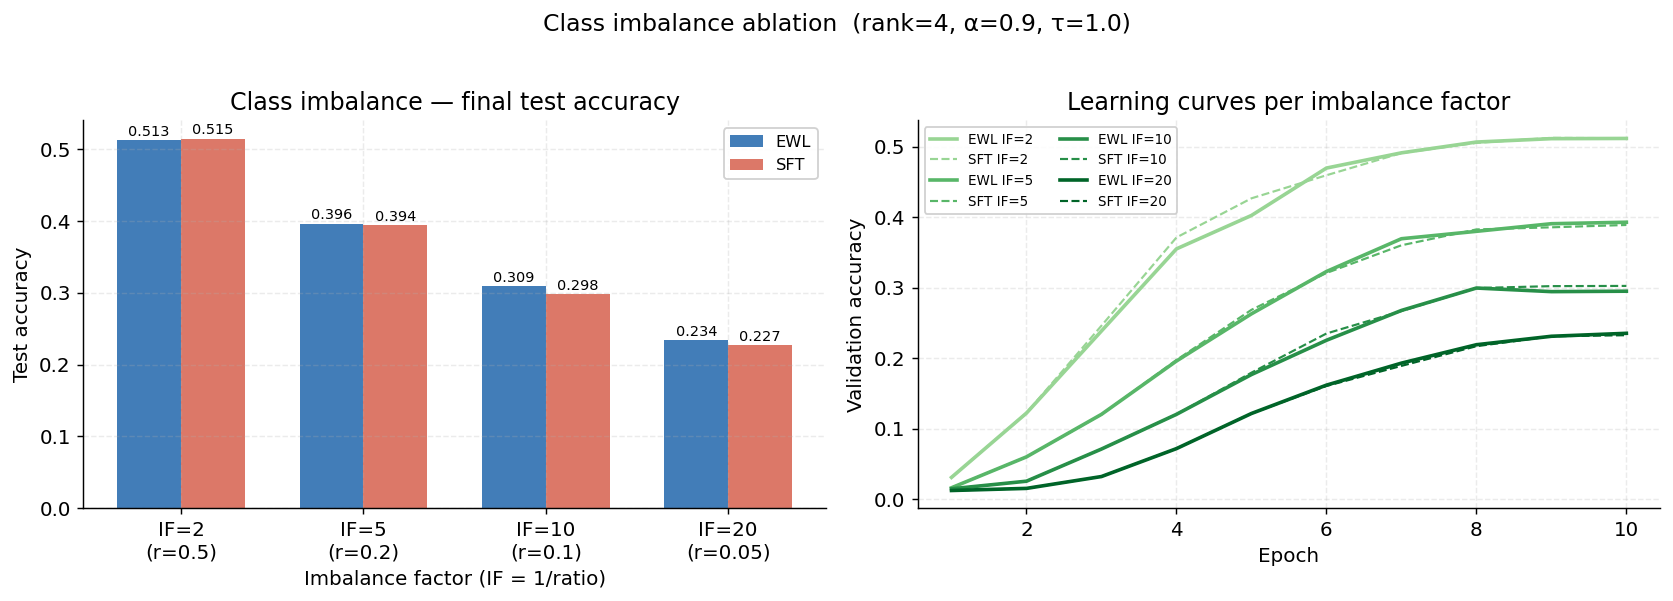

EWL test acc: ['0.5128', '0.3963', '0.3093', '0.2340']
SFT test acc: ['0.5146', '0.3942', '0.2982', '0.2274']
Δ (EWL−SFT): ['-0.0018', '+0.0021', '+0.0111', '+0.0066']


In [185]:
# Sorted from mild to severe: 50 > 20 > 10 > 5
IMB_CODES   = [50, 20, 10, 5]   # as stored in dir name
IMB_RATIOS  = [0.5, 0.2, 0.1, 0.05]  # n_min/n_max
IMB_IF      = [2, 5, 10, 20]          # imbalance factor = 1/ratio

imb = df_ni[df_ni.sweep == 'imbalance'].copy()

acc_ewl_i = [imb[(imb.condition=='ewl') & (imb['value']==v)]['test_acc'].values for v in IMB_CODES]
acc_sft_i = [imb[(imb.condition=='sft') & (imb['value']==v)]['test_acc'].values for v in IMB_CODES]

y_ewl_i = [a[0] if len(a) else float('nan') for a in acc_ewl_i]
y_sft_i = [a[0] if len(a) else float('nan') for a in acc_sft_i]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: bar chart
xs = np.arange(len(IMB_CODES))
bars_e = axes[0].bar(xs - w/2, y_ewl_i, w, color=C['ewl'], alpha=0.85, label='EWL')
bars_s = axes[0].bar(xs + w/2, y_sft_i, w, color=C['sft'], alpha=0.85, label='SFT')
for bar, y in list(zip(bars_e, y_ewl_i)) + list(zip(bars_s, y_sft_i)):
    if not np.isnan(y):
        axes[0].text(bar.get_x() + bar.get_width()/2, y + 0.002,
                     f'{y:.3f}', ha='center', va='bottom', fontsize=8)
axes[0].set_xticks(xs)
axes[0].set_xticklabels([f'IF={f}\n(r={r})' for f, r in zip(IMB_IF, IMB_RATIOS)])
axes[0].set_xlabel('Imbalance factor (IF = 1/ratio)')
axes[0].set_ylabel('Test accuracy')
axes[0].set_title('Class imbalance — final test accuracy')
axes[0].legend()

# Right: learning curves (val_acc)
imb_colors = plt.cm.Greens(np.linspace(0.4, 0.9, len(IMB_CODES)))
for code, if_, col in zip(IMB_CODES, IMB_IF, imb_colors):
    for cond, ls in [('ewl', '-'), ('sft', '--')]:
        sub = imb[(imb.condition==cond) & (imb['value']==code)]
        ep, mu, _ = get_curves(sub, 'val_acc')
        if len(ep) == 0: continue
        lbl = f'{cond.upper()} IF={if_}'
        axes[1].plot(ep, mu, color=col, lw=2 if cond=='ewl' else 1.2,
                     ls=ls, label=lbl)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation accuracy')
axes[1].set_title('Learning curves per imbalance factor')
axes[1].legend(fontsize=7.5, ncol=2)

plt.suptitle(f'Class imbalance ablation  (rank={NI_RANK}, α={NI_ALPHA}, τ={NI_TEMP})', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('EWL test acc:', [f'{v:.4f}' for v in y_ewl_i])
print('SFT test acc:', [f'{v:.4f}' for v in y_sft_i])
print('Δ (EWL−SFT):', [f'{e-s:+.4f}' for e, s in zip(y_ewl_i, y_sft_i)])

## Figure 8 — EWL advantage (Δ accuracy) across perturbation levels
Positive = EWL wins, negative = SFT wins.  Note: single seed (11), so treat as exploratory.

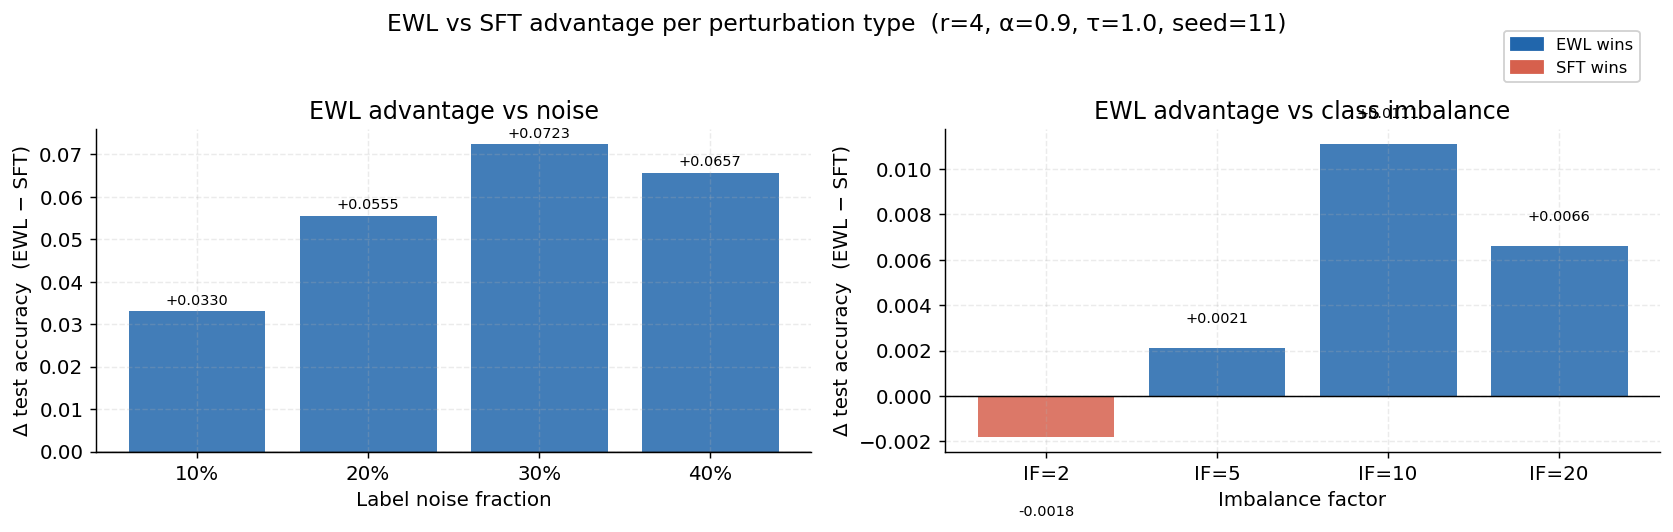

--- Noise sweep ---
  noise 10%: Δ=+0.0330  [EWL]
  noise 20%: Δ=+0.0555  [EWL]
  noise 30%: Δ=+0.0723  [EWL]
  noise 40%: Δ=+0.0657  [EWL]
--- Imbalance sweep ---
  IF= 2:      Δ=-0.0018  [SFT]
  IF= 5:      Δ=+0.0021  [EWL]
  IF=10:      Δ=+0.0111  [EWL]
  IF=20:      Δ=+0.0066  [EWL]


In [186]:
delta_noise = [e - s for e, s in zip(y_ewl_n, y_sft_n)]
delta_imb   = [e - s for e, s in zip(y_ewl_i, y_sft_i)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Noise delta
bar_colors_n = [C['ewl'] if d >= 0 else C['sft'] for d in delta_noise]
axes[0].bar(range(len(NOISE_LEVELS)), delta_noise, color=bar_colors_n, alpha=0.85)
axes[0].axhline(0, color='black', lw=0.8)
for i, d in enumerate(delta_noise):
    axes[0].text(i, d + (0.001 if d >= 0 else -0.003),
                 f'{d:+.4f}', ha='center',
                 va='bottom' if d >= 0 else 'top', fontsize=8)
axes[0].set_xticks(range(len(NOISE_LEVELS)))
axes[0].set_xticklabels([f'{v}%' for v in NOISE_LEVELS])
axes[0].set_xlabel('Label noise fraction')
axes[0].set_ylabel('Δ test accuracy  (EWL − SFT)')
axes[0].set_title('EWL advantage vs noise')

# Imbalance delta
bar_colors_i = [C['ewl'] if d >= 0 else C['sft'] for d in delta_imb]
axes[1].bar(range(len(IMB_IF)), delta_imb, color=bar_colors_i, alpha=0.85)
axes[1].axhline(0, color='black', lw=0.8)
for i, d in enumerate(delta_imb):
    axes[1].text(i, d + (0.001 if d >= 0 else -0.003),
                 f'{d:+.4f}', ha='center',
                 va='bottom' if d >= 0 else 'top', fontsize=8)
axes[1].set_xticks(range(len(IMB_IF)))
axes[1].set_xticklabels([f'IF={f}' for f in IMB_IF])
axes[1].set_xlabel('Imbalance factor')
axes[1].set_ylabel('Δ test accuracy  (EWL − SFT)')
axes[1].set_title('EWL advantage vs class imbalance')

# Shared legend patch
from matplotlib.patches import Patch
legend_el = [Patch(color=C['ewl'], label='EWL wins'), Patch(color=C['sft'], label='SFT wins')]
fig.legend(handles=legend_el, loc='upper right', bbox_to_anchor=(0.98, 1.02))

plt.suptitle(f'EWL vs SFT advantage per perturbation type  (r={NI_RANK}, α={NI_ALPHA}, τ={NI_TEMP}, seed={NI_SEED})', fontsize=13, y=1.04)
plt.tight_layout()
plt.show()

# Quick summary
print('--- Noise sweep ---')
for v, d in zip(NOISE_LEVELS, delta_noise):
    winner = 'EWL' if d > 0 else ('TIE' if d == 0 else 'SFT')
    print(f'  noise {v:2d}%: Δ={d:+.4f}  [{winner}]')
print('--- Imbalance sweep ---')
for if_, d in zip(IMB_IF, delta_imb):
    winner = 'EWL' if d > 0 else ('TIE' if d == 0 else 'SFT')
    print(f'  IF={if_:2d}:      Δ={d:+.4f}  [{winner}]')